# Гипотеза 5. Метод k-ближайших соседей (k-NN)

## 5.1. Постановка гипотезы

**Гипотеза:** Клиенты с близким социально-демографическим профилем (возраст, профессия, баланс) демонстрируют схожее поведение в отношении открытия срочного вклада. Метод k-ближайших соседей, непосредственно эксплуатирующий локальную структуру данных, способен уловить данную закономерность.

**Алгоритм:** Метод k-ближайших соседей (k-Nearest Neighbors, k-NN).

**Обоснование выбора алгоритма:**

1. Разведочный анализ данных выявил выраженную кластерную структуру: студенты и пенсионеры открывают вклады значительно чаще, чем представители других профессий. k-NN напрямую использует близость объектов в признаковом пространстве.
2. Алгоритм является непараметрическим и не делает предположений о распределении данных.
3. Нормализация числовых признаков посредством `StandardScaler` выполнена на этапе подготовки данных — обязательное условие корректной работы k-NN, поскольку алгоритм чувствителен к масштабу признаков.
4. Гипотеза носит контрастный характер: ожидается, что k-NN уступит ансамблевым методам (H2, H3), однако позволит оценить степень геометрической разделимости классов в признаковом пространстве.

## 5.2. Управляемые гиперпараметры

| Гиперпараметр | Описание | Диапазон поиска |
|---|---|---|
| `n_neighbors` | Число ближайших соседей k | `[3, 5, 7, 11, 15, 21]` |
| `weights` | Схема взвешивания соседей | `['uniform', 'distance']` |
| `metric` | Метрика расстояния | `['euclidean', 'manhattan']` |

## 5.3. Критерии качества

- **ROC-AUC** — основная метрика; устойчива к дисбалансу классов.
- **F1-score** для класса «yes» — баланс точности и полноты для целевого класса.
- **Classification Report** — детализированные метрики по каждому классу.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

%store -r X
%store -r y

## 5.4. Процедура подбора гиперпараметров

Применяется метод полного перебора (`GridSearchCV`) в сочетании со стратифицированной 5-кратной перекрёстной проверкой. Пространство гиперпараметров невелико, что делает полный перебор вычислительно приемлемым. Целевая метрика оптимизации — `roc_auc`.

Примечание: k-NN не имеет встроенного механизма взвешивания классов. Дисбаланс частично компенсируется параметром `weights='distance'`, при котором более близкие соседи получают больший вес.

In [2]:
RUN_SEARCH = False  # True — повторный подбор гиперпараметров

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

BEST_PARAMS = {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}

if RUN_SEARCH:
    param_grid = {
        'n_neighbors': [3, 5, 7, 11, 15, 21],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
    search = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1
    )
    search.fit(X, y)
    best_model = search.best_estimator_
    print(f"Оптимальные гиперпараметры: {search.best_params_}")
    print(f"ROC-AUC (CV): {search.best_score_:.4f}")
else:
    best_model = KNeighborsClassifier(**BEST_PARAMS)
    print(f"Используются сохранённые гиперпараметры: {BEST_PARAMS}")

## 5.5. Анализ зависимости ROC-AUC от числа соседей k

На рисунке представлена зависимость среднего ROC-AUC по фолдам от числа соседей `k` для каждой комбинации `weights` и `metric`.

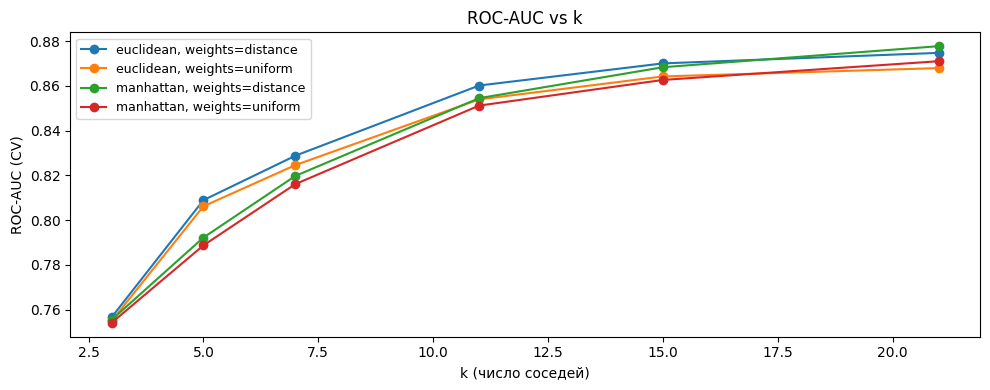

In [3]:
results_df = pd.DataFrame(search.cv_results_)
results_df['label'] = results_df['params'].apply(
    lambda p: f"{p['metric']}, weights={p['weights']}"
)

fig, ax = plt.subplots(figsize=(10, 4))
for label, g in results_df.groupby('label'):
    g = g.sort_values('param_n_neighbors')
    ax.plot(g['param_n_neighbors'], g['mean_test_score'], marker='o', label=label)
ax.set_xlabel('k (число соседей)')
ax.set_ylabel('ROC-AUC (CV)')
ax.set_title('ROC-AUC vs k')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5.6. Оценка качества оптимальной модели

Оценка производится методом out-of-fold (OOF) на стратифицированных разбиениях.

In [4]:

y_pred_oof = np.zeros(len(y))
y_proba_oof = np.zeros(len(y))

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    best_model.fit(X_train, y_train)
    y_pred_oof[val_idx] = best_model.predict(X_val)
    y_proba_oof[val_idx] = best_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y, y_proba_oof)
f1 = f1_score(y, y_pred_oof)

print(f"ROC-AUC (OOF): {roc_auc:.4f}")
print(f"F1-score (класс 'yes'): {f1:.4f}")
print()
print(classification_report(y, y_pred_oof, target_names=['no', 'yes']))

## 5.7. Оптимизация порога классификации

k-NN не поддерживает `class_weight`, однако оптимизация порога позволяет частично скомпенсировать склонность модели к предсказанию доминирующего класса.

Оптимальный порог: 0.17
F1-score при пороге 0.50: 0.1086
F1-score при оптимальном пороге: 0.5279

              precision    recall  f1-score   support

          no       0.95      0.90      0.93      4000
         yes       0.46      0.63      0.53       521

    accuracy                           0.87      4521
   macro avg       0.70      0.76      0.73      4521
weighted avg       0.89      0.87      0.88      4521



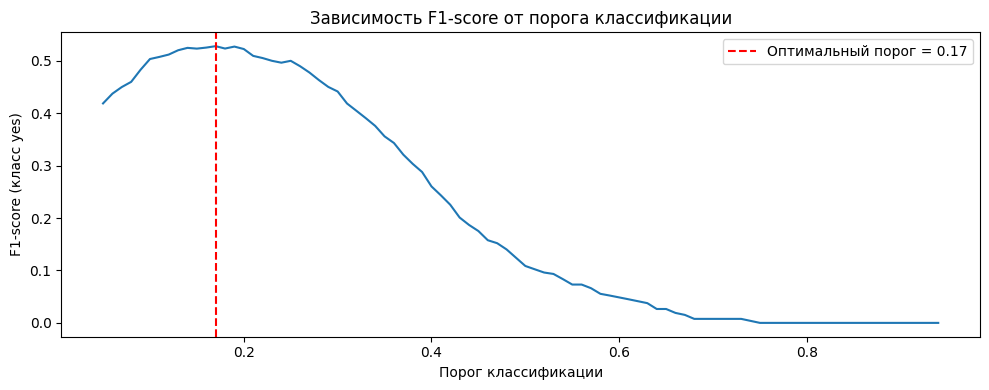

In [5]:
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores_thresh = [f1_score(y, (y_proba_oof >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores_thresh)]
y_pred_opt = (y_proba_oof >= best_threshold).astype(int)

print(f"Оптимальный порог: {best_threshold:.2f}")
print(f"F1-score при пороге 0.50: {f1:.4f}")
print(f"F1-score при оптимальном пороге: {f1_score(y, y_pred_opt):.4f}")
print()
print(classification_report(y, y_pred_opt, target_names=['no', 'yes']))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores_thresh)
ax.axvline(best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('F1-score (класс yes)')
ax.set_title('Зависимость F1-score от порога классификации')
ax.legend()
plt.tight_layout()
plt.show()

## 5.8. ROC-кривая и матрица ошибок при оптимальном пороге

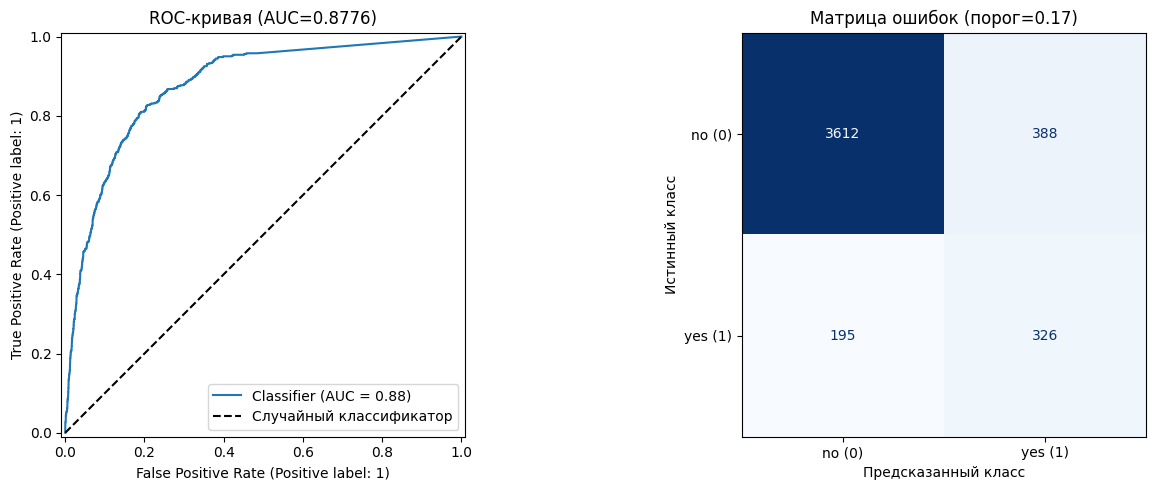

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y, y_proba_oof, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
axes[0].set_title(f'ROC-кривая (AUC={roc_auc:.4f})')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_opt,
    display_labels=['no (0)', 'yes (1)'],
    cmap='Blues',
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title(f'Матрица ошибок (порог={best_threshold:.2f})')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

## 5.9. Выводы

По результатам проверки гипотезы 5 установлено следующее:

1. При стандартном пороге 0.5 k-NN демонстрирует крайне низкий Recall для класса «yes» (F1=0.11), что объясняется отсутствием встроенного механизма взвешивания классов.
2. Оптимизация порога существенно улучшает F1-score для класса «yes», однако результат остаётся хуже, чем у ансамблевых методов (H2, H3) и метрических моделей с регуляризацией (H1, H4).
3. Основная причина относительно низкого качества — **проклятие размерности** (curse of dimensionality): после One-Hot Encoding пространство признаков содержит 44 измерения, и евклидово расстояние теряет разделяющую способность в многомерном пространстве.
4. Гипотеза частично опровергнута: локальная структура данных (близость профилей клиентов) не является достаточным основанием для высококачественной классификации при данной размерности признакового пространства.